In [2]:
import pandas as pd
import numpy as np
import warnings
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Importamos la librería principal
from neuralforecast import NeuralForecast
from neuralforecast.losses.pytorch import MSE, MAE

# Importamos los 4 modelos del Benchmark
from neuralforecast.models import LSTM, NHITS, PatchTST, TCN

warnings.filterwarnings('ignore')
pd.options.display.float_format = '{:.5f}'.format

print("✅ Entorno configurado correctamente.")

✅ Entorno configurado correctamente.


In [3]:
# --- 1. CARGA DE DATOS ---
filename = "dataset_tfm_56_survivors.csv"

if os.path.exists(filename):
    df = pd.read_csv(filename)
    df['ds'] = pd.to_datetime(df['ds'])
    
    # --- 2. FILTRO DE SEGURIDAD (CRÍTICO) ---
    # Eliminamos empresas que no tengan datos suficientes para el año 2023 + ventana de entreno
    # 60 (input) + 5 (horizonte) + 260 (validación) + margen
    MIN_DAYS = 335
    
    counts = df.groupby('unique_id').size().reset_index(name='n_days')
    valid_ids = counts[counts['n_days'] > MIN_DAYS]['unique_id'].unique()
    
    df = df[df['unique_id'].isin(valid_ids)].copy()
    print(f"📊 Empresas válidas para el estudio: {df['unique_id'].nunique()} (de {len(counts)})")

    # --- 3. PREPROCESAMIENTO ---
    # Limpieza de outliers extremos
    df = df[(df['y'] <= 0.5) & (df['y'] >= -0.5)].copy()
    
    # Normalización Z-Score por empresa
    stats = df.groupby('unique_id')['y'].agg(['mean', 'std']).reset_index()
    df = pd.merge(df, stats, on='unique_id', how='left')
    df['y_norm'] = (df['y'] - df['mean']) / (df['std'] + 1e-8)

    # DataFrame Final
    df_final = df.copy()
    df_final['y_raw'] = df_final['y']       # Guardamos original
    df_final['y'] = df_final['y_norm']      # Usamos normalizado
    df_final = df_final[['unique_id', 'ds', 'y', 'y_raw']].dropna()
    df_final = df_final.sort_values(by=['unique_id', 'ds']).reset_index(drop=True)
    
    # --- 4. CONFIGURACIÓN DE VALIDACIÓN ---
    VAL_YEAR = 2023
    df_input = df_final.copy()
    
    # Calculamos el tamaño de validación (días en 2023)
    df_2023 = df_input[df_input['ds'].dt.year == VAL_YEAR]
    val_size = int(df_2023.groupby('unique_id').size().median())
    
    print(f"✅ Datos listos.")
    print(f"   Input Size: 60 días")
    print(f"   Horizonte: 5 días")
    print(f"   Validation Size (2023): {val_size} días")

else:
    print(f"❌ ERROR FATAL: No encuentro el archivo '{filename}'.")

📊 Empresas válidas para el estudio: 56 (de 56)
✅ Datos listos.
   Input Size: 60 días
   Horizonte: 5 días
   Validation Size (2023): 255 días


In [9]:
# Configuración Global
HORIZONTE = 5
INPUT_SIZE = 60
MAX_STEPS = 500  # Pasos de entrenamiento (ajustable)

print("🚀 INICIANDO ENTRENAMIENTO DE BENCHMARK...")

# --- 1. LSTM (Recurrente Clásico) ---
# Mejor config: Hidden 256, Layers 2
lstm = LSTM(
    h=HORIZONTE,
    input_size=INPUT_SIZE,
    loss=MSE(), valid_loss=MAE(),
    max_steps=MAX_STEPS,
    scaler_type='identity',
    start_padding_enabled=True,
    # Parámetros específicos
    encoder_hidden_size=256,
    decoder_hidden_size=256,
    encoder_n_layers=2,
    decoder_layers=2,
    alias='LSTM_Best'
)

# --- 2. NHITS (MLP Moderno) ---
# Mejor config: Hidden 512, Blocks 2
nhits = NHITS(
    h=HORIZONTE,
    input_size=INPUT_SIZE,
    loss=MSE(), valid_loss=MAE(),
    max_steps=MAX_STEPS,
    scaler_type='identity',
    start_padding_enabled=True,
    # Parámetros específicos
    n_freq_downsample=[2, 1, 1],
    mlp_units=[[512, 512]] * 3,   # 3 Stacks de 512
    n_blocks=[2, 2, 2],           # 2 bloques por stack
    alias='NHITS_Best'
)

# --- 3. PatchTST (Transformer Univariante) ---
# Mejor config: Patch 8, Hidden 64
patchtst = PatchTST(
    h=HORIZONTE,
    input_size=INPUT_SIZE,
    loss=MSE(), valid_loss=MAE(),
    max_steps=MAX_STEPS,
    scaler_type='identity',
    start_padding_enabled=True,
    # Parámetros específicos
    patch_len=8,
    hidden_size=64,
    n_heads=4,
    encoder_layers=2,
    alias='PatchTST_Best'
)

# --- 4. TCN (Convolucional) ---
# Mejor config: Hidden 64, Layers 4
tcn = TCN(
    h=HORIZONTE,
    input_size=INPUT_SIZE,
    loss=MSE(), valid_loss=MAE(),
    max_steps=MAX_STEPS,
    scaler_type='identity',
    start_padding_enabled=True,
    # Parámetros específicos
    kernel_size=3,
    encoder_hidden_size=64,
    dilations=[1, 2, 4, 8], # 4 capas dilatadas
    alias='TCN_Best'
)

# --- EJECUCIÓN DEL TORNEO ---
models = [lstm, nhits, patchtst, tcn]

nf = NeuralForecast(models=models, freq='B') # 'B' = Business days

# Entrenar
nf.fit(df=df_input, val_size=val_size)
print("✅ Entrenamiento completado.")

Seed set to 1
Seed set to 1
Seed set to 1
Seed set to 1
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


🚀 INICIANDO ENTRENAMIENTO DE BENCHMARK...



  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | loss         | MSE           | 0      | train | 0    
1 | valid_loss   | MAE           | 0      | train | 0    
2 | padder_train | ConstantPad1d | 0      | train | 0    
3 | scaler       | TemporalNorm  | 0      | train | 0    
4 | hist_encoder | LSTM          | 791 K  | train | 0    
5 | mlp_decoder  | MLP           | 66.0 K | train | 0    
---------------------------------------------------------------
857 K     Trainable params
0         Non-trainable params
857 K     Total params
3.430     Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode
0         Total Flops


Epoch 249: 100%|██████████| 2/2 [00:00<00:00,  2.74it/s, v_num=74, train_loss_step=0.816, train_loss_epoch=0.833, valid_loss=0.548]

`Trainer.fit` stopped: `max_steps=500` reached.


...

Epoch 249: 100%|██████████| 2/2 [00:00<00:00, 12.36it/s, v_num=76, train_loss_step=1.050, train_loss_epoch=1.040, valid_loss=0.556]


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name            | Type                       | Params | Mode  | FLOPs
-------------------------------------------------------------------------------
0 | loss            | MSE                        | 0      | train | 0    
1 | valid_loss      | MAE                        | 0      | train | 0    
2 | padder_train    | ConstantPad1d              | 0      | train | 0    
3 | scaler          | TemporalNorm               | 0      | train | 0    
4 | hist_encoder    | TemporalConvolutionEncoder | 37.3 K | train | 0    
5 | context_adapter | Linear                     | 305    | train | 0    
6 | mlp_decoder     | MLP                        | 8.4 K  | train | 0    
-------------------------------------------------------------------------------
46.1 K    Trainable params
0         Non-trainable params
46.1 K    Total params
0.184     Total estimated model params size 

Epoch 249: 100%|██████████| 2/2 [00:00<00:00, 14.46it/s, v_num=77, train_loss_step=0.820, train_loss_epoch=0.836, valid_loss=0.548]

`Trainer.fit` stopped: `max_steps=500` reached.


Epoch 249: 100%|██████████| 2/2 [00:00<00:00, 14.25it/s, v_num=77, train_loss_step=0.820, train_loss_epoch=0.836, valid_loss=0.548]
✅ Entrenamiento completado.


In [10]:
print("📊 CALCULANDO MÉTRICAS...")

# 1. Predecir sobre el set de validación (2023)
# Cortamos los datos para simular que estamos a 1 de Enero de 2023
cutoff_date = f"{VAL_YEAR}-01-01"
df_history = df_input[df_input['ds'] < cutoff_date].copy()

# Generamos predicciones
forecasts = nf.predict(df=df_history).reset_index()

# 2. Unir con valores reales
combined = pd.merge(forecasts, df_input[['unique_id', 'ds', 'y']], on=['unique_id', 'ds'], how='inner')

# 3. Calcular Métricas para cada Modelo
model_names = ['LSTM_Best', 'NHITS_Best', 'PatchTST_Best', 'TCN_Best']
results_list = []

# Volatilidad real de entrada (para calcular correlación)
vol_data = []
for uid in df_history['unique_id'].unique():
    series = df_history[df_history['unique_id']==uid]['y']
    # Si la serie es muy corta, ponemos 0 para evitar error, aunque el filtro ya lo evita
    v = series.tail(INPUT_SIZE).std() if len(series) >= INPUT_SIZE else 0
    vol_data.append({'unique_id': uid, 'Input_Vol': v})
df_vol = pd.DataFrame(vol_data)

for m in model_names:
    # Error Global (MAE)
    mae_global = (combined['y'] - combined[m]).abs().mean()
    
    # Error por Empresa para Robustez
    errors_per_id = combined.groupby('unique_id').apply(
        lambda x: (x['y'] - x[m]).abs().mean()
    ).reset_index(name='MAE_Empresa')
    
    # Análisis de Correlación
    analysis = pd.merge(df_vol, errors_per_id, on='unique_id')
    corr = analysis['Input_Vol'].corr(analysis['MAE_Empresa'])
    
    results_list.append({
        'Modelo': m.replace('_Best', ''),
        'MAE': mae_global,
        'Correlacion': corr
    })

# Añadimos MANUALMENTE tu iTransformer (Benchmark) para comparar
results_list.append({
    'Modelo': 'iTransformer',
    'MAE': 0.6340,      # Tu dato
    'Correlacion': 0.5000 # Tu dato
})

df_results = pd.DataFrame(results_list).sort_values('MAE')
print("\n🏆 RESULTADOS FINALES:")
print(df_results.to_string(index=False))

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


📊 CALCULANDO MÉTRICAS...
Predicting DataLoader 0: 100%|██████████| 2/2 [00:00<00:00, 66.67it/s]


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting DataLoader 0: 100%|██████████| 2/2 [00:00<00:00, 100.45it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



Predicting DataLoader 0: 100%|██████████| 2/2 [00:00<00:00, 120.54it/s]


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting DataLoader 0: 100%|██████████| 2/2 [00:00<00:00, 151.71it/s]

🏆 RESULTADOS FINALES:
      Modelo     MAE  Correlacion
iTransformer 0.63400      0.50000
    PatchTST 0.65536      0.40760
         TCN 0.67187      0.36849
        LSTM 0.67206      0.36526
       NHITS 0.67925      0.39686


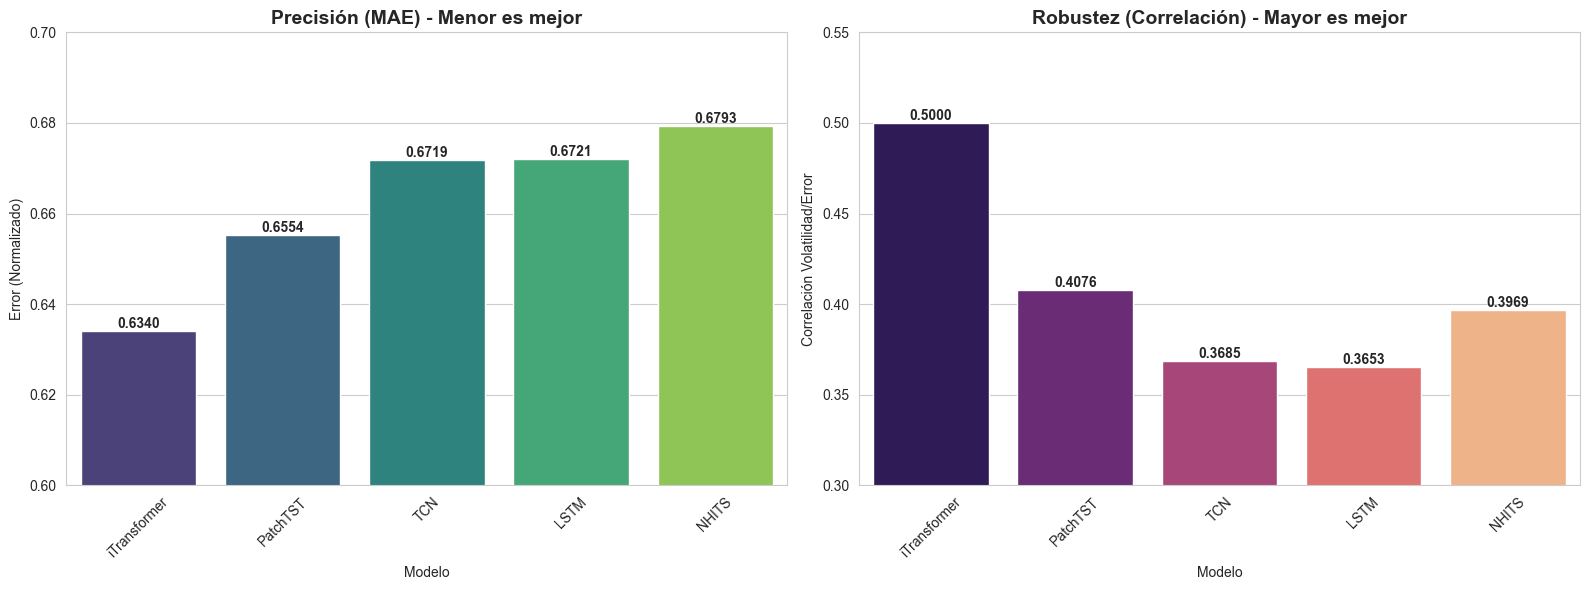

✅ Gráficos generados y guardados como 'Benchmark_Final_TFM.png'


In [11]:
# Configuración Visual
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Definir colores: Destacar iTransformer
colors = ['grey' if 'iTransformer' not in x else 'red' for x in df_results['Modelo']]

# --- GRÁFICO 1: MAE ---
sns.barplot(data=df_results, x='Modelo', y='MAE', ax=axes[0], palette='viridis')
axes[0].set_title('Precisión (MAE) - Menor es mejor', fontsize=14, fontweight='bold')
axes[0].set_ylim(0.60, 0.70) # Zoom para ver diferencias
axes[0].set_ylabel('Error (Normalizado)')
axes[0].tick_params(axis='x', rotation=45)

for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.4f}', 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontweight='bold')

# --- GRÁFICO 2: ROBUSTEZ ---
sns.barplot(data=df_results, x='Modelo', y='Correlacion', ax=axes[1], palette='magma')
axes[1].set_title('Robustez (Correlación) - Mayor es mejor', fontsize=14, fontweight='bold')
axes[1].set_ylim(0.30, 0.55)
axes[1].set_ylabel('Correlación Volatilidad/Error')
axes[1].tick_params(axis='x', rotation=45)

for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.4f}', 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('Benchmark_Final_TFM.png', dpi=300)
plt.show()

print("✅ Gráficos generados y guardados como 'Benchmark_Final_TFM.png'")

C:\Users\ferfp\AppData\Local\Temp\ipykernel_1832\3905230410.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


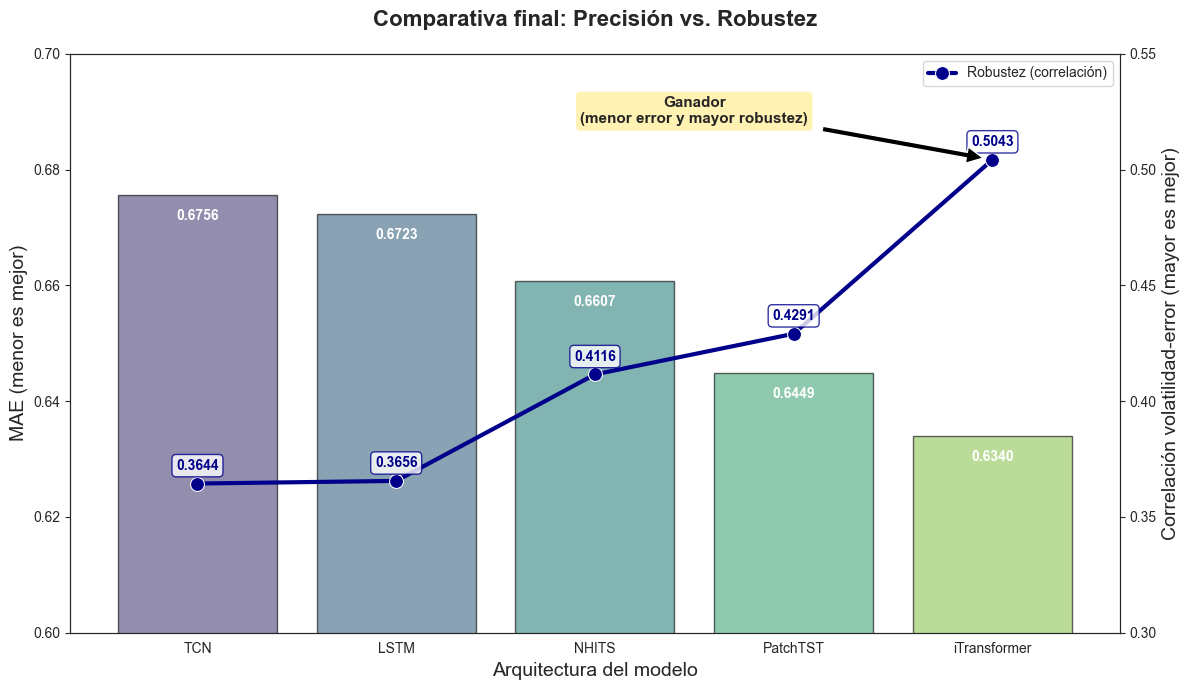

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. DATOS EXACTOS PROPORCIONADOS
data = {
    'Modelo': ['TCN', 'LSTM', 'NHITS', 'PatchTST', 'iTransformer'],
    # He reordenado los modelos de "Peor" a "Mejor" (según MAE) para que la gráfica cuente una historia visual
    'MAE': [
        0.675595563605459, 
        0.6722627889117805, 
        0.6607021748217786, 
        0.6449001067431007, 
        0.63398
    ],
    'Correlacion': [
        0.3644380723672666, 
        0.3655724353062598, 
        0.41156887280001897, 
        0.42912862009547936, 
        0.5043
    ]
}

df_final = pd.DataFrame(data)

# 2. CONFIGURACIÓN DEL GRÁFICO DE DOBLE EJE
fig, ax1 = plt.subplots(figsize=(12, 7))
sns.set_style("white") # Fondo limpio

# --- EJE Y IZQUIERDO: MAE (BARRAS) ---
# Usamos una paleta secuencial suave, destacando al iTransformer con un color diferente si se desea,
# o simplemente un degradado. Aquí usaremos un degradado de rojos (Error = Malo/Alerta)
bars = sns.barplot(
    data=df_final, 
    x='Modelo', 
    y='MAE', 
    ax=ax1, 
    palette="viridis", 
    alpha=0.6,
    edgecolor="black"
)

ax1.set_ylabel('MAE (menor es mejor)', fontsize=14)
ax1.tick_params(axis='y')
ax1.set_ylim(0.60, 0.70) # Ajustamos el zoom para que se aprecien las diferencias (ya que son márgenes estrechos)

# Añadir valores sobre las barras
for p in bars.patches:
    ax1.annotate(f'{p.get_height():.4f}', 
                 (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha = 'center', va = 'center', 
                 xytext = (0, -15), textcoords = 'offset points',
                 color='white', fontweight='bold', fontsize=10)

# --- EJE Y DERECHO: CORRELACIÓN (LÍNEA) ---
ax2 = ax1.twinx()
# Usamos una línea verde o azul fuerte (Correlación = Bueno/Robustez)
sns.lineplot(
    data=df_final, 
    x='Modelo', 
    y='Correlacion', 
    ax=ax2, 
    color='darkblue', 
    marker='o', 
    markersize=10, 
    linewidth=3,
    label='Robustez (correlación)'
)

ax2.set_ylabel('Correlación volatilidad-error (mayor es mejor)', fontsize=14)
ax2.tick_params(axis='y')
ax2.set_ylim(0.30, 0.55)
ax2.grid(False) # Quitamos el grid del eje secundario para no ensuciar

# Añadir valores sobre los puntos de la línea
for i, txt in enumerate(df_final['Correlacion']):
    ax2.annotate(f'{txt:.4f}', 
                 (i, df_final['Correlacion'][i]), 
                 xytext=(0, 10), textcoords='offset points',
                 ha='center', color='darkblue', fontweight='bold', fontsize=10,
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="darkblue", alpha=0.8))

# 3. DETALLES FINALES
plt.title('Comparativa final: Precisión vs. Robustez', fontsize=16, fontweight='bold', pad=20)
ax1.set_xlabel('Arquitectura del modelo', fontsize=14)

# Flecha indicando el ganador
plt.annotate('Ganador\n(menor error y mayor robustez)', 
             xy=(4, 0.5043), xytext=(2.5, 0.52),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=11, fontweight='bold', ha='center',
             bbox=dict(boxstyle="round,pad=0.3", fc="gold", alpha=0.3))

plt.tight_layout()
plt.savefig('benchmark_final_comparison.png', dpi=300)
plt.show()